Initialize Instruction Memory, Data Memory, and Program

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Simulation perameters
Max_steps = 10000
signal_size = 1000


Generate signals

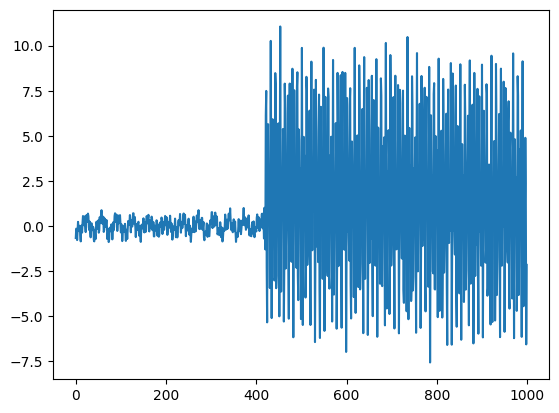

In [19]:
t = np.linspace(0, signal_size, num=signal_size)
s_norm = np.random.randn(signal_size)

n_comp = 5


#Generating random signal components
amps = np.random.uniform(0.01,20,n_comp)
freqs = np.random.uniform(0.01,200,n_comp)
phases = np.random.uniform(0,2*np.pi,n_comp)

for i in range(n_comp):
    s_norm += amps[i]*np.sin(2*np.pi*freqs[i]*t + phases[i])

#Normalze signal
s_norm = s_norm/np.max(s_norm)
#plt.plot(s_norm)

#Generating Earthquake signals:
amps = np.random.uniform(0.1,5,n_comp)
freqs = np.random.uniform(0.1,30,n_comp)
phases = np.random.uniform(0,2*np.pi,n_comp)

eq = np.zeros(signal_size)
for i in range(n_comp):
    eq += amps[i]*np.sin(2*np.pi*freqs[i]*t + phases[i])

#plt.plot(eq)

#To recreate an earthquake scenario, we'll take a portion of the earthquake signal, and add it to the noisy signal
eq_sample = np.copy(eq)
eq_start = np.random.randint(100,800)
eq_sample[0:eq_start] = 0
s_meassured = s_norm + eq_sample

plt.plot(s_meassured)

s_meassured = np.append(s_meassured,np.zeros(Max_steps-signal_size))


Accellerator Layout
-

Earth Quake Detected!


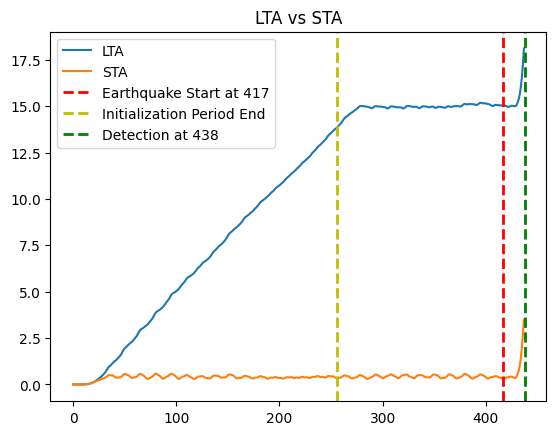

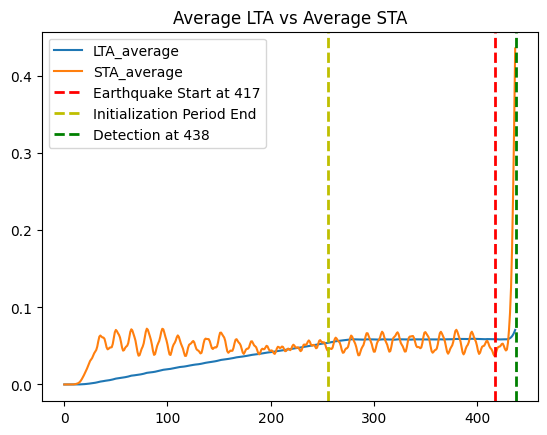

Earthquake Detected!
Detection Time: 21 cycles after earthquake started
Throughput: 0.4155251141552511 , CPI: 2.406593406593407
Throughput after initialization: 1.0
CPI after initialization: 1
Efficency: 41.55251141552511


In [42]:
#A few new types of circular buffers are created here. The first one has double the capacity. This buffer stores a second copy of the value being pushed, which allows the buffer to push out the values of the buffer in order
class double_buffer:
  def __init__(self,size):
    self.size = 2*size
    self.N = size
    self.head = 0
    self.count = 0
    self.buffer = np.zeros(self.size)

  def push(self,x):
    self.buffer[self.head] = x
    self.buffer[self.head + self.N] = x
    self.head = (self.head + 1)%self.N

  def get_alligned(self):
    return self.buffer[self.head:self.head + self.N]

#Another type used includes two additional buffers. This is used to keep track of the last filtered energy values placed into STA and LTA
class energy_buffer:
  def __init__(self,size):
    self.size = size
    self.head = 0
    self.count = 0
    self.buffer = np.zeros(self.size)

  def push(self,x):
    self.buffer[self.head] = x
    self.head = (self.head + 1)%self.size

  def get_delayed(self,k):
    return self.buffer[(self.head - k)% self.size]

#This code generates the weight coefficents for the BPF. These would be calculater before hand and stored in a register for easy access
def gen_BPF(f_upper,f_lower,fs,N):
  H = np.zeros(N,dtype=complex)
  f_content = np.fft.fftfreq(N,1/fs)

  for i, f in enumerate(f_content):
    if f_lower <= abs(f) <= f_upper:
      H[i] = 1
    else:
      H[i] = 0

  h = np.fft.ifft(H).real
  h = np.roll(h,N//2)
  return h


NL = 256 #Long term average size
Ns = 8 #Short term average size
Ne = 10 #Energy buffer size
num_acc_stages = 8

f_upper = 30
f_lower = 0.1
fs = 200
N = 16 #Input Buffer size

T = 2**2 #Threshold Value
detecion = 0 #An internal flag is used to trigger earthquake early warning system
stalled = 0 # Used to pause the cycle counter

in_buff = double_buffer(N)
energy_buff = double_buffer(Ne)
filtered_en_buff = energy_buffer(NL)
acc_pipeline = np.zeros((num_acc_stages,NL))

#Generate BPF weights
w1 = gen_BPF(f_upper,f_lower,fs,N)
w1 = w1[::-1]

#Smoothing filter that responds fast to sudden changes, but smooths out smaller ones
w2 = np.array([0.8**k for k in range(1,Ne+1)])
w2 = w2 / np.sum(w2)

'''For each clock cycle the accellerator will:
1) Load in the new data for the cicrular buffer
2) Send the data from the buffer into the first fiter stage (Using MAC and stored weights)
   - We need to make sure the data and the weights are alligned for this part
3) Send the filtered data into squarer to produce energy
4) Send energy into a second circular filter
5) Use second filter stage to smooth data
6) Push the smoothed data into another circular buffer
7) Reuse previous data to compute STA AND LTA'''

'''Assumptions:
1) All values within the vectorized registers are alligned
2) ...'''


step = 0
i = 0


#These values are stored in registers and get updated continuously
STA = 0
LTA = 0

LTA_vals = []
STA_vals = []
LTA_ave_vals = []
STA_ave_vals = []

while (step < Max_steps):

  #Used to compute throughput. No useful information comes out while initializing
  if(step < NL):
    stalled += 1

  #Eight Stage - Compareison
  if ((STA * NL > LTA*T *Ns) and (i>NL)):
    print("Earth Quake Detected!")
    acc_pipeline[7] = np.ones_like(acc_pipeline[7])
    acc_pipeline[7][0] = LTA
    acc_pipeline[7][1] = STA
    detecion = 1

  #Seventh Stage - Calculate LTA and STA
  LTA += filtered_en_buff.buffer[(filtered_en_buff.head - 1)%filtered_en_buff.size] - filtered_en_buff.get_delayed(NL)
  STA += filtered_en_buff.buffer[(filtered_en_buff.head - 1)%filtered_en_buff.size] - filtered_en_buff.get_delayed(Ns)
  LTA_vals.append(LTA)
  STA_vals.append(STA)
  LTA_ave_vals.append(LTA/NL)
  STA_ave_vals.append(STA/Ns)

  acc_pipeline[6][0] = STA
  acc_pipeline[6][1] = LTA

  #Sixth stage - Push smoothed value into circular filter
  acc_pipeline[5] = filtered_en_buff.buffer

  #Fifth stage - Smoothing filter, and storage into circular buffer 3
  acc_pipeline[4][0] = np.sum(acc_pipeline[3][:Ne]*w2)

  #Fourth stage - Save calculated energy into energy buffer
  acc_pipeline[3][:Ne] = energy_buff.get_alligned()

  #Third Stage - Calcularte energy (x^2)
  acc_pipeline[2][0] = np.square(acc_pipeline[1][0]) # Fix: Square the scalar output of the previous stage

  #2nd Stage - Bandpass FIR
  acc_pipeline[1][0] = np.sum(acc_pipeline[0][:N]*w1) # Fix: Use the first N elements of acc_pipeline[0]

  #1st Stage - Push values of input circular buffer
  acc_pipeline[0][:N] = in_buff.get_alligned() # Fix: Assign to a slice of acc_pipeline[0] to match shape
  step += 1

  #Update Buffer
  in_buff.push(s_meassured[i])
  energy_buff.push(acc_pipeline[2][0])
  filtered_en_buff.push(acc_pipeline[4][0])
  i += 1

  #print(f"Step {i}:")
  #print(f'Input: {s_meassured[i-1]}')
  #print(acc_pipeline)

  if (detecion == 1):
    break



#Plotting Results
plt.title("LTA vs STA")
plt.plot(LTA_vals,label='LTA')
plt.plot(STA_vals,label='STA')
plt.axvline(x=eq_start, color='r', linestyle='--', linewidth=2,label=f'Earthquake Start at {eq_start}')
plt.axvline(x=NL, color='y', linestyle='--', linewidth=2,label='Initialization Period End')
plt.axvline(x=step, color='g', linestyle='--', linewidth=2,label=f'Detection at {step}')
plt.legend()
plt.show()

plt.title("Average LTA vs Average STA")
plt.plot(LTA_ave_vals,label='LTA_average')
plt.plot(STA_ave_vals,label='STA_average')
plt.axvline(x=eq_start, color='r', linestyle='--', linewidth=2,label=f'Earthquake Start at {eq_start}')
plt.axvline(x=NL, color='y', linestyle='--', linewidth=2,label='Initialization Period End')
plt.axvline(x=step, color='g', linestyle='--', linewidth=2,label=f'Detection at {step}')
plt.legend()
plt.show()

if (detecion == 1):
  print("Earthquake Detected!")
  print(f'Detection Time: {step-eq_start} cycles after earthquake started')

throughput = (step - stalled) / step #Essentially, useful cycles over total cycles
CPI = 1/throughput
useful_cycles = step - stalled
efficency = (useful_cycles/step)*100
print(f'Throughput: {throughput} , CPI: {CPI}')
print(f'Throughput after initialization: {(step-stalled)/(step-stalled)}')
print(f'CPI after initialization: 1')
print(f'Efficency: {efficency}')

CPU Metrics

In [45]:

CPU_cycles = 0
e_buffer = np.zeros(Ne)
LTA1 = 0
STA1 = 0
old_lta = 0
old_sta = 0
sta_buffer = np.zeros(Ns)
lta_buffer = np.zeros(NL)
sample_num = 0
sta_idx = 0
lta_idx = 0
Eq_start_cycles = 0
for j in range(Max_steps):

  y = 0
  for k in range(N):
    if j - k >= 0:
      y += w1[k]*s_meassured[j-k]
    CPU_cycles += 2

  e = y*y
  e_buffer[j%Ne] = e
  CPU_cycles += 1

  s = 0
  for k in range(Ne):
    idx = (j - k) % Ne
    s += w2[k] * e_buffer[idx]
    CPU_cycles += 2

  old_sta = sta_buffer[sta_idx]
  old_lta = lta_buffer[lta_idx]

  STA1 += s - old_sta
  LTA1 += s - old_lta

  sta_buffer[sta_idx] = s
  lta_buffer[lta_idx] = s

  sta_idx = (sta_idx + 1) % Ns
  lta_idx = (lta_idx + 1) % NL

  CPU_cycles += 4

  CPU_cycles += 4

  if (j == eq_start):
    eq_start_cycles = CPU_cycles
  if (STA1 * NL > LTA1*T *Ns) and (j>NL):
    print("Earth Quake Detected!")
    break

print(f'Total Cycles: {CPU_cycles}')
speedup = CPU_cycles / step
print(f'Speedup: {speedup}%')
print(f'Cycles till detection: {CPU_cycles - eq_start_cycles}')





Earth Quake Detected!
Total Cycles: 25986
Speedup: 59.32876712328767%
Cycles till detection: 488
